In [1]:
# Check python version
#@title Imports (RUN ME!) { display-mode: "form" }
import sys,os
sys.version

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
#path to images
root_dir = "/home/research/classify_drone_images/"
os.listdir(root_dir)

['single_fence', 'double_fence']

In [3]:
path = os.path.join(root_dir)

# EDA

In [5]:
#view files
for file, folder in [('fence.csv','fence'),('fences.csv','fences')]:
    print(file)
    print(folder)


fence.csv
fence
fences.csv
fences


In [6]:
# view files
for f in os.listdir(path):
    print(f)

single_fence
double_fence


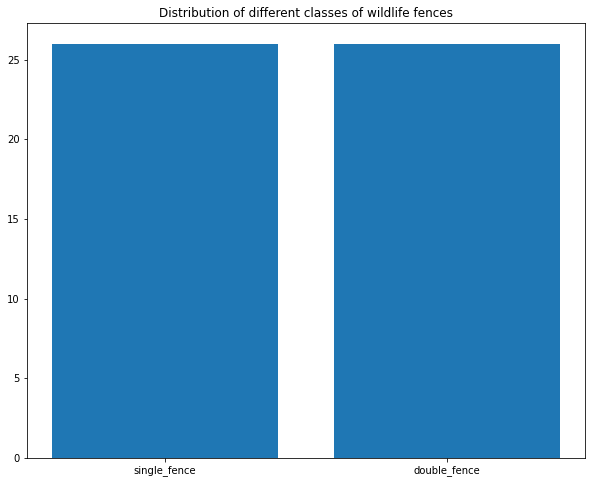

In [7]:
image_folder = ['single_fence', 'double_fence']
nimgs = {}
for i in image_folder:
    nimages = len(os.listdir(path+i+'/'))
    nimgs[i]=nimages
plt.figure(figsize=(10, 8))
plt.bar(range(len(nimgs)), list(nimgs.values()), align='center')
plt.xticks(range(len(nimgs)), list(nimgs.keys()))
plt.title('Distribution of different classes of wildlife fences')
plt.show()

In [8]:
for i in ['single_fence', 'double_fence']:
    print('Valid {} images are: '.format(i)+str(len(os.listdir(path+i+'/'))))

Valid single_fence images are: 26
Valid double_fence images are: 26


## Generate Dataset

In [9]:
img_width, img_height = 256, 256 #256, 256
image_size = (img_width, img_height)
batch_size = 12

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
    #labels='inferred',
    #label_mode = 'categorical'
    
    
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
    #labels='inferred',
    #label_mode = 'categorical'
)

Found 52 files belonging to 2 classes.
Using 42 files for training.
Found 52 files belonging to 2 classes.
Using 10 files for validation.


In [10]:
class_names = train_ds.class_names
print(class_names)

['double_fence', 'single_fence']


### Visualize the data
Here are the first 9 images in the training dataset. As you can see, we have label single_fence and double_fence

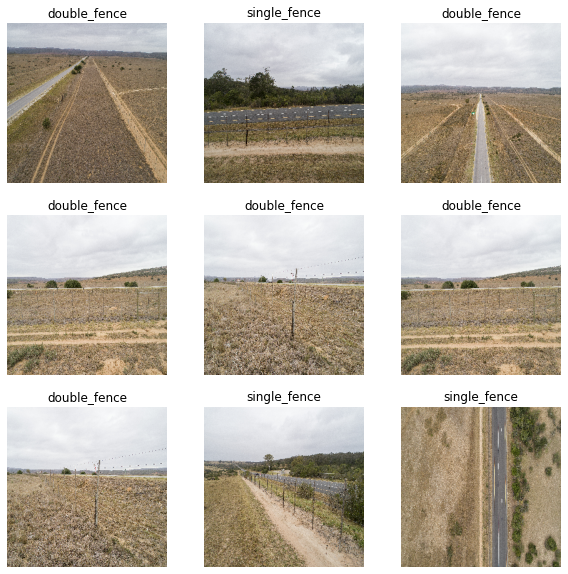

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

The `image_batch` is a tensor of the shape `(12, 256, 256, 3)`. This is a batch of 32 images of shape `256x256x3` (the last dimension refers to color channels RGB). The `label_batch` is a tensor of the shape `(12,)`, these are corresponding labels to the 12 images. 

You can call `.numpy()` on the `image_batch` and `labels_batch` tensors to convert them to a `numpy.ndarray`.


In [12]:
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(12, 256, 256, 3)
(12,)


### Using image data augmentation
Very helpful when you don't have a large image dataset, it's a good practice to artificially introduce sample diversity by applying random yet realistic transformations to the training images, such as random horizontal flipping or small random rotations. This helps expose the model to different aspects of the training data while slowing down overfitting.

In [13]:

data_augmentation = tf.keras.Sequential([
  layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical", input_shape=(img_height, img_width,3)),
  layers.experimental.preprocessing.RandomRotation(0.2),
    layers.experimental.preprocessing.RandomZoom(0.1),
])

visualizing augmented samples, by applying data_augmentation repeatedly to the first 9 images in the dataset

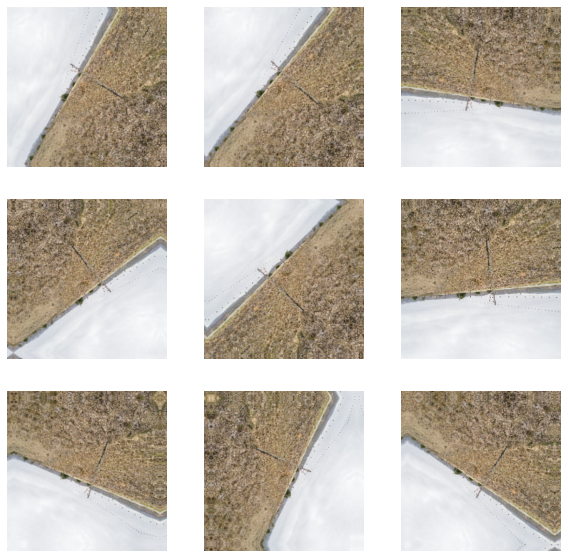

In [14]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

### Standardizing the data
The image dataset is in a standard size (256x256) since they are represented as as contiguous float32 batches. And, their RGB channel values are in the [0, 255] range which not ideal for a NN. Standadizing means aiming to make the input values small. Here, we will standardize values to be in the [0, 1] by using a Rescaling layer at the start of our model.




In [15]:
normalization_layer = layers.experimental.preprocessing.Rescaling(1./255)

In [16]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


### Configure the dataset for performance

Let's make sure to use buffered prefetching, so you can yield data from disk without having I/O become blocking. These are two important methods you should use when loading data.

`.cache()` keeps the images in memory after they're loaded off disk during the first epoch. This will ensure the dataset does not become a bottleneck while training your model. If your dataset is too large to fit into memory, you can also use this method to create a performant on-disk cache.

`.prefetch()` overlaps data preprocessing and model execution while training. 
Refer to  [data performance guide](https://www.tensorflow.org/guide/data_performance#prefetching).

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Build Model

The standard model consists of three convolution blocks with a max pool layer in each of them. There's a fully connected layer with 15 units on top of it that is activated by a relu activation function. 



In [18]:
num_classes = 2

model = Sequential([
  data_augmentation ,
  layers.experimental.preprocessing.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(10, 3, padding='same'),
  layers.BatchNormalization(),
  layers.Activation('relu'),
  layers.MaxPooling2D(pool_size=(2, 2)),
  layers.Dropout(0.1),
  
    
  #layers.Conv2D(32, 3, padding='same'),
  #layers.BatchNormalization(),
  #layers.Activation('relu'),
  #layers.MaxPooling2D(),
    
  #layers.Conv2D(64, 3, padding='same'),
  #layers.BatchNormalization(),
  #layers.Activation('relu'),
  #layers.MaxPooling2D(),
    
  layers.Flatten(),
  layers.Dense(15),
  layers.BatchNormalization(),
  layers.Activation('relu'),
  #layers.Dropout(0.1),
  layers.Dense(num_classes)
])


# Train Model

In [ ]:
filepath = "/home/research/models/classify_drone_images/"+"save_at_{epoch}.h5"
filepath

In [20]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='loss',patience=20, restore_best_weights=True)
checkpoint = [
    keras.callbacks.ModelCheckpoint(filepath),
]

In [21]:
epochs = 200
model.compile(
    #optimizer = keras.optimizers.RMSprop(learning_rate=lr_schedule),
    optimizer=tf.keras.optimizers.Adam(1e-3),#),# , 10e-6
    #optimizer = keras.optimizers.RMSprop(learning_rate=lr_schedule),
    #optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
     loss="sparse_categorical_crossentropy",#categorical_crossentropy",#loss='sparse_categorical_crossentropy',
         metrics=['accuracy'],
)

In [22]:
history=model.fit(train_ds, epochs=epochs, callbacks = [early_stop, checkpoint], validation_data=val_ds)


Epoch 1/200
4/4 [==============================] - 8s 818ms/step - loss: 2.9623 - accuracy: 0.6667 - val_loss: 7.8396 - val_accuracy: 0.5000
Epoch 2/200
4/4 [==============================] - 1s 237ms/step - loss: 0.8244 - accuracy: 0.5952 - val_loss: 3.5504 - val_accuracy: 0.5000
Epoch 3/200
4/4 [==============================] - 1s 239ms/step - loss: 2.0801 - accuracy: 0.7857 - val_loss: 3.4925 - val_accuracy: 0.5000
Epoch 4/200
4/4 [==============================] - 1s 232ms/step - loss: 1.1694 - accuracy: 0.6905 - val_loss: 3.4591 - val_accuracy: 0.5000
Epoch 5/200
4/4 [==============================] - 1s 232ms/step - loss: 0.7490 - accuracy: 0.7619 - val_loss: 3.4257 - val_accuracy: 0.5000
Epoch 6/200
4/4 [==============================] - 1s 231ms/step - loss: 1.0787 - accuracy: 0.7619 - val_loss: 3.3410 - val_accuracy: 0.5000
Epoch 7/200
4/4 [==============================] - 1s 233ms/step - loss: 1.0934 - accuracy: 0.6905 - val_loss: 3.3684 - val_accuracy: 0.5000
Epoch 8/200
4

### visualising the results

In [23]:
# Loss Curves
def plot_curves(history):
    plt.figure(figsize=[14,10])
    plt.subplot(211)
    plt.plot(history.history['loss'],'r',linewidth=3.0)
    plt.plot(history.history['val_loss'],'b',linewidth=3.0)
    plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
    plt.xlabel('Epochs ',fontsize=16)
    plt.ylabel('Loss',fontsize=16)
    plt.title('Loss Curves for Aerial Images',fontsize=16)
    
    # Accuracy Curves
    plt.figure(figsize=[14,10])
    plt.subplot(212)
    plt.plot(history.history['accuracy'],'r',linewidth=3.0)
    plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
    plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
    plt.xlabel('Epochs ',fontsize=16)
    plt.ylabel('Accuracy',fontsize=16)
    plt.title('Accuracy Curves for Aerial Images',fontsize=16)

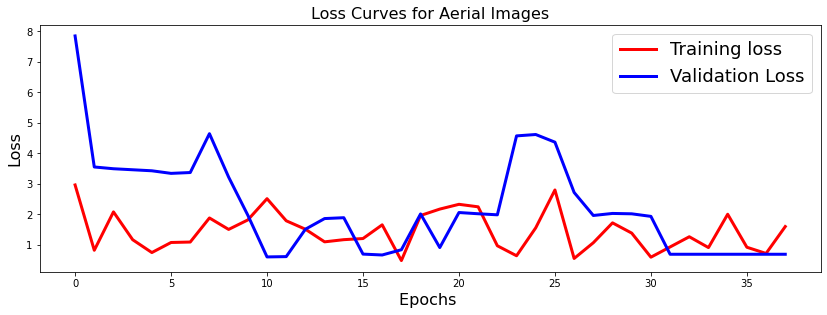

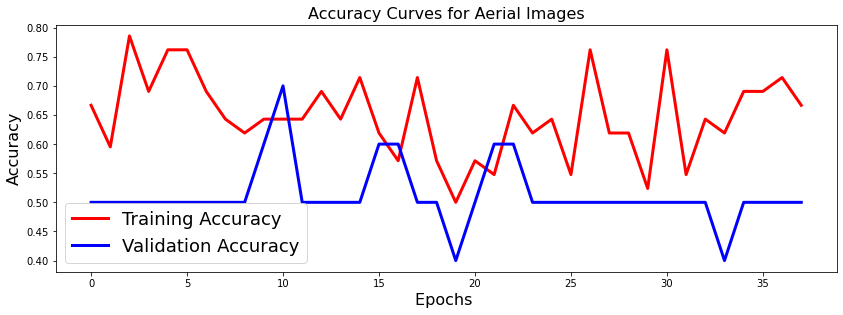

In [24]:
plot_curves(history)

# Make predictions 
With the model trained, you can use it to make predictions about some images. The model's linear outputs, logits. Attach a softmax layer to convert the logits to probabilities, which are easier to interpret. 

In [25]:
probability_model = tf.keras.Sequential([model, 
                                         tf.keras.layers.Softmax()])


In [26]:
predictions = probability_model.predict(val_ds)


Here, the model has predicted the label for each image in the testing set. Let's take a look at the first prediction:

In [27]:
predictions[0]


array([0.4620133, 0.5379867], dtype=float32)

A prediction is an array of 2 numbers. They represent the model's "confidence" that the image corresponds to each of the 2 different images of fences. You can see which label has the highest confidence value:

In [28]:
np.argmax(predictions[0])


1

So, the model is most confident that this image is an double fence, or class_names[1]. Examining the val label shows that this classification is correct:

In [29]:
# get the labels 
predictions = np.array([])
labels =  np.array([])

for x, y in val_ds:
    predictions = np.concatenate([predictions, np.argmax(model.predict(x), axis=-1)])
    labels = np.concatenate([labels, y.numpy()])

In [30]:
predictions

array([1., 1., 1., 0., 1., 0., 1., 1., 1., 1.])

In [31]:
len(predictions)

10

In [32]:
labels

array([0., 1., 0., 1., 1., 0., 0., 1., 1., 0.])

In [33]:
len(labels)

10

In [34]:
m = tf.keras.metrics.Accuracy()
m(labels, predictions).numpy()


0.5

In [35]:
#cf_matrix = confusion_matrix(labels, predictions)
#fig, ax = plt.subplots(figsize=(5,5))
#sns.heatmap(cf_matrix, linewidths=1, annot=True, ax=ax, fmt='g')

In [36]:
#cm = confusion_matrix(labels, predictions)
#fig = plt.figure(figsize = (8,8))
#ax1 = fig.add_subplot(1,1,1)
#sns.set(font_scale=1) #for label size
#sns.heatmap(cm, annot=True, annot_kws={"size": 12},
    # cbar = False, cmap='Purples');
#ax1.set_ylabel('True Values',fontsize=14)
#ax1.set_xlabel('Predicted Values',fontsize=14)
#plt.show()

In [37]:
#labels that were not predicted
set(labels) - set(predictions)

set()

In [38]:
# this shows that you are not interested in the labels that were not predicted
# we are interested in the labels that were predicted at least once
from sklearn.metrics import f1_score
f1_score(labels, predictions,  average='weighted', labels=np.unique(predictions))
#0.91076923076923078

0.45054945054945056

In [39]:
print('Classification Report')
target_names = ['single_fence', 'double_fence']
print(classification_report(labels, predictions, target_names=target_names, labels=np.unique(predictions)))

Classification Report
              precision    recall  f1-score   support

single_fence       0.50      0.20      0.29         5
double_fence       0.50      0.80      0.62         5

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.45        10
weighted avg       0.50      0.50      0.45        10



**Test the Model Performance**

### Single Image

In [40]:
img = keras.preprocessing.image.load_img(
    path+"single_fence/Rhodes-University-Location-1-Image-Data (99).jpg", target_size=image_size
)


In [41]:
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis


In [42]:
predictions = probability_model.predict(img_array)
score = predictions[0]


In [43]:
print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)


This image most likely belongs to single_fence with a 55.65 percent confidence.


In [44]:
print(
    "This image most likely does not belong to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmin(score)], 100 * np.min(score))
)

This image most likely does not belong to double_fence with a 44.35 percent confidence.


#### Let us see how our model performs on the testing data. Remember, the testing data is the data the model hasn’t seen during the training process.

In [45]:
# loading the best perfoming model
loaded_model = tf.keras.models.load_model("/home/nandutu/research/models/classify_drone_images/"+"save_at_74.h5")

# Getting test accuracy and loss
test_loss, test_acc = model.evaluate(val_ds)
print('Test loss: {} Test Acc: {}'.format(test_loss, test_acc))

1/1 [==============================] - 0s 78ms/step - loss: 0.8408 - accuracy: 0.5000
Test loss: 0.840840220451355 Test Acc: 0.5


#### We get a test loss of approximately 0.8408 and a test accuracy of approximately 0.5000